<a href="https://colab.research.google.com/github/aanappaula/AnaliseSUS/blob/master/Analise_SUS_UBS_AnaPaula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Dados do SUS – UBS


## Objetivo

Este trabalho apresenta uma análise exploratória de dados das Unidades Básicas de Saúde (UBS) do SUS no Brasil.

A análise utiliza:

- Pandas
- Matplotlib
- GeoPandas

Além disso, foram identificados insights sobre distribuição geográfica e concentração das UBS.


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point


## Upload do arquivo CSV

In [2]:

from google.colab import files

uploaded = files.upload()


Saving Unidades_Basicas_Saude-UBS.csv to Unidades_Basicas_Saude-UBS.csv


In [4]:

ubs = pd.read_csv('Unidades_Basicas_Saude-UBS.csv', sep=';')

ubs.head()


,CNES,UF,IBGE,NOME,LOGRADOURO,BAIRRO,LATITUDE,LONGITUDE
0,23914,31,310620,CENTRO DE SAUDE JARDIM MONTANHES,RUA SAUDE,PADRE EUSTAQUIO,-19.911503,"-43,9914089036"
1,106143,26,261000,UBS FRANCISCO VIEIRA DE MELO,QUADRA 50,QUILOMBO II,-8.705590,"-35,5995386839"
2,302,26,260290,USF SANTO ESTEVAO,RUA DO CEMITERIO,PONTE DOS CARVALHOS,-8.218112,"-35,2294359"
3,405132,26,261350,UNIDADE DE SAUDE SABINO LUCAS DE BARROS,TRAVESSA SAO PAULO,VILA DELMIRO,-7.866081,"-38,7650871277"
4,881007,26,261000,UBS MARIA ALICE,QUADRA 11,QUILOMBO 2,-8.698513,"-35,6040179729"


In [7]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=ubs)

https://docs.google.com/spreadsheets/d/1jObKkREsMeFY9NxRvSRGI3tuGLqH_wpW_gHNoBRIVvk/edit#gid=0


## Informações gerais da base

In [5]:

ubs.shape


(47673, 8)

In [6]:

ubs.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47673 entries, 0 to 47672
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CNES        47673 non-null  int64  
 1   UF          47673 non-null  int64  
 2   IBGE        47673 non-null  int64  
 3   NOME        47672 non-null  object 
 4   LOGRADOURO  47673 non-null  object 
 5   BAIRRO      47673 non-null  object 
 6   LATITUDE    45744 non-null  float64
 7   LONGITUDE   45745 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 2.9+ MB


In [8]:

ubs.isnull().sum()


,0
CNES,0
UF,0
IBGE,0
NOME,1
LOGRADOURO,0
BAIRRO,0
LATITUDE,1929
LONGITUDE,1928



### Insight

A base possui milhares de registros de UBS distribuídos em todo o Brasil.


## Tratamento dos dados

In [10]:

ubs['LONGITUDE'] = (
    ubs['LONGITUDE']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

ubs['LONGITUDE'] = pd.to_numeric(ubs['LONGITUDE'], errors='coerce')
ubs['LATITUDE'] = pd.to_numeric(ubs['LATITUDE'], errors='coerce')

ubs = ubs.dropna(subset=['LATITUDE', 'LONGITUDE'])


## Quantidade de UBS por estado

In [11]:

ubs_por_estado = ubs['UF'].value_counts().sort_values(ascending=False)

ubs_por_estado.head(10)


,count
UF,
31,5816
35,5509
29,4351
26,2922
23,2399
21,2321
41,2278
43,2218
33,2160


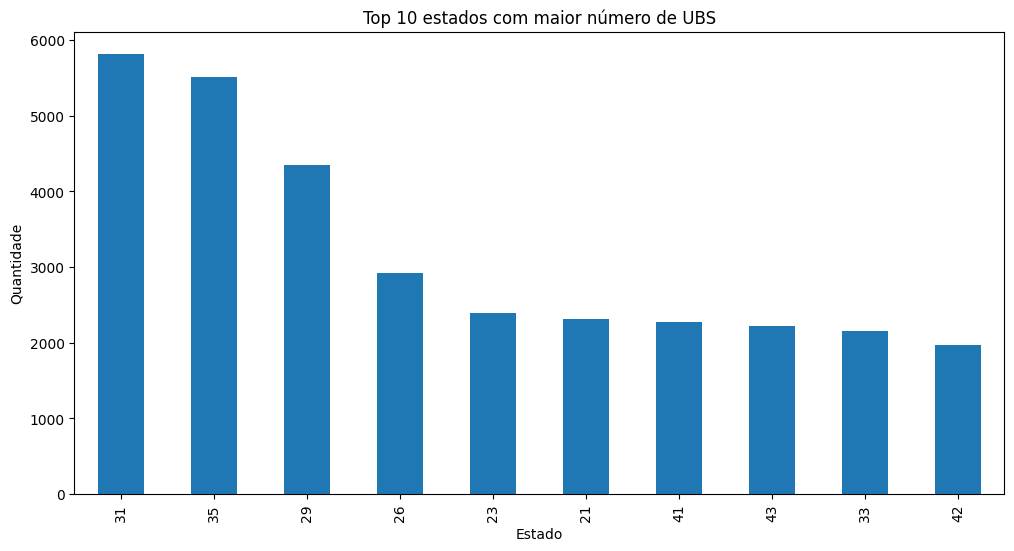

In [12]:

plt.figure(figsize=(12,6))

ubs_por_estado.head(10).plot(kind='bar')

plt.title('Top 10 estados com maior número de UBS')
plt.xlabel('Estado')
plt.ylabel('Quantidade')

plt.show()



### Insight

Os estados mais populosos concentram maior número de UBS.


## Bairros com maior número de UBS

In [13]:

ubs['BAIRRO'].value_counts().head(10)


,count
BAIRRO,
CENTRO,9300
ZONA RURAL,4662
RURAL,288
BELA VISTA,238
POVOADO,227
SANTO ANTONIO,199
VILA NOVA,180
SAO JOSE,179
SAO FRANCISCO,172



### Insight

Regiões urbanas apresentam maior concentração de unidades de saúde.


## Criando GeoDataFrame

In [14]:

geometry = [Point(xy) for xy in zip(ubs['LONGITUDE'], ubs['LATITUDE'])]

geo_ubs = gpd.GeoDataFrame(ubs, geometry=geometry)

geo_ubs.head()


,CNES,UF,IBGE,NOME,LOGRADOURO,BAIRRO,LATITUDE,LONGITUDE,geometry
0,23914,31,310620,CENTRO DE SAUDE JARDIM MONTANHES,RUA SAUDE,PADRE EUSTAQUIO,-19.911503,-43.991409,POINT (-43.99141 -19.9115)
1,106143,26,261000,UBS FRANCISCO VIEIRA DE MELO,QUADRA 50,QUILOMBO II,-8.705590,-35.599539,POINT (-35.59954 -8.70559)
2,302,26,260290,USF SANTO ESTEVAO,RUA DO CEMITERIO,PONTE DOS CARVALHOS,-8.218112,-35.229436,POINT (-35.22944 -8.21811)
3,405132,26,261350,UNIDADE DE SAUDE SABINO LUCAS DE BARROS,TRAVESSA SAO PAULO,VILA DELMIRO,-7.866081,-38.765087,POINT (-38.76509 -7.86608)
4,881007,26,261000,UBS MARIA ALICE,QUADRA 11,QUILOMBO 2,-8.698513,-35.604018,POINT (-35.60402 -8.69851)


## Mapa das UBS

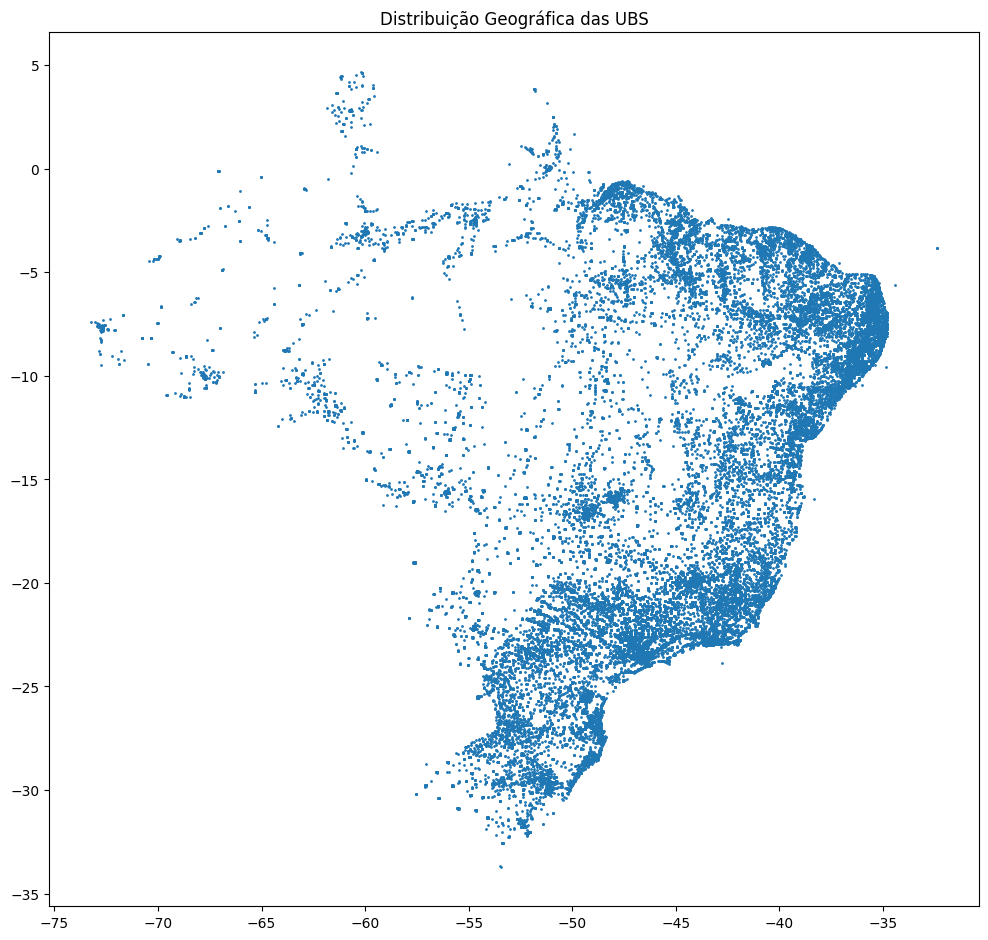

In [15]:

fig, ax = plt.subplots(figsize=(12,12))

geo_ubs.plot(ax=ax, markersize=1)

plt.title('Distribuição Geográfica das UBS')

plt.show()



### Insight

A maior concentração de UBS está nas regiões Sudeste e Nordeste.


## Municípios com mais UBS

In [16]:

ubs['IBGE'].value_counts().head(10)


,count
IBGE,
355030,554
330455,341
130260,254
530010,199
261160,179
292740,176
310620,169
431490,157
230440,139



## Conclusão

A análise mostrou:

- Forte concentração de UBS em regiões mais populosas;
- Distribuição desigual entre estados;
- Importância da análise geográfica em dados de saúde pública.

O uso do GeoPandas facilita análises espaciais e visualizações importantes para gestão pública.
